In [1]:
from notebooks.two_layer_controlled_sample import lengths
%load_ext autoreload
%autoreload 2
import cyl_lvm as spr

import os
import tqdm
import numpy as np
import pandas as pd

import socceraction.spadl as spadl

In [2]:
datafolder = "../data"
fifa2018h5 = os.path.join(datafolder, "spadl-fifa2018.h5")
games = pd.read_hdf(fifa2018h5, key="games")
with pd.HDFStore(fifa2018h5) as store:
    actions = []  #list of DataFrames
    for game in tqdm.tqdm(games.itertuples()):
        game_action = store[f"actions/game_{game.game_id}"]
        game_action = spadl.play_left_to_right(game_action, game.home_team_id)
        game_action["is_home"] = game_action["team_id"] == game.home_team_id
        actions.append(game_action)
    actions = pd.concat(actions)
    actions.drop("original_event_id", axis=1, inplace=True)
    actions = pd.merge(actions, spadl.config.actiontypes_df(), how="left")

64it [00:00, 174.61it/s]


In [3]:
ACTION_MAP = {#'clearance': 0,
              'corner': 1,
              'cross': 2,
              'dribble': 3,
              'freekick': 4,
              'goalkick': 5,
              'keeper_action': 6,
              'pass': 7,
              'shot': 8,
              'throw_in': 9}

ACTION_MAP = {'clearance': 0,
              'corner': 10,
              'cross': 7,
              'dribble': 3,
              'freekick': 10,
              'goalkick': 10,
              'keeper_action': 10,
              'pass': 7,
              'shot': 8,
              'throw_in': 10}

X, lenghts = spr.prepare_data(actions, ACTION_MAP)

In [4]:
emission_hyperparams = {#'clearance': [3, "k-means",2,"k-means"],
              'corner': [2, "k-means",2,"k-means"],
              'cross': [3, "k-means",2,"k-means"],
              'dribble': [3, "k-means",2,"k-means"],
              'freekick': [2, "k-means",2,"k-means"],
              'goalkick': [2, "k-means",2,"k-means"],
              'keeper_action': [2, "k-means",2,"k-means"],
              'pass': [3, "k-means",2,"k-means"],
              'shot': [2, "k-means",2,"k-means"],
              'throw_in': [2, "k-means",2,"k-means"]}

emission_hyperparams = {
        'starting' : [6 , "k-means",2,"k-means"],
        'pass': [4, "k-means",2,"k-means"],
        'dribble' : [4, "k-means",2,"k-means"],
        'shot' : [2, "k-means",1,"k-means"]
                }

models = {n_states: spr.TwoLayerHMM(emission_hyperparams, n_states)
          for n_states in range(3,4)}


In [5]:
models[3].fit(X, lenghts)

/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hierarchical/two_layer.py:449: RuntimeWarning: divide by zero encountered in log
  return logsumexp(np.log(layer1_pdf) + layer2_log_pdf, axis=1)  # (N,)


,emission_hyperparams,"{'dribble': [4, 'k-means', ...], 'pass': [4, 'k-means', ...], 'shot': [2, 'k-means', ...], 'starting': [6, 'k-means', ...]}"
,n_components,3
,ignore_actions,False
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'


In [22]:
models[3].export_model_params()

{'n_components': 3,
 'n_features': 5,
 'startprob': [0.09441219559542759, 0.3620404340416545, 0.5435473703629179],
 'transmat': [[0.971034164304668, 0.0032288657020473166, 0.025736969993284658],
  [0.7677081882715957, 0.00026854800300596816, 0.23202326372539833],
  [0.01656207231910729, 0.12075299883232159, 0.8626849288485711]],
 'emission': {'ignore_actions': False,
  'model_actions': ['starting', 'pass', 'dribble', 'shot'],
  'hyperparams': {'starting': [6, 'k-means', 2, 'k-means'],
   'pass': [4, 'k-means', 2, 'k-means'],
   'dribble': [4, 'k-means', 2, 'k-means'],
   'shot': [2, 'k-means', 1, 'k-means']},
  'action_pi': [{'starting': 8.957597012109013e-05,
    'pass': 0.50037375591166,
    'dribble': 0.48113082550983144,
    'shot': 0.018405842608391253},
   {'starting': 0.23102189277591956,
    'pass': 0.5073562053876606,
    'dribble': 0.2609443127345205,
    'shot': 0.0006775891018947805},
   {'starting': 0.024244328086162392,
    'pass': 0.48899860371775755,
    'dribble': 0.48

In [14]:
saved = {'n_components': 3,
 'n_features': 5,
 'startprob': [0.043644600183247645, 0.6932339659567197, 0.2631214338600326],
 'transmat': [[0.9758442614343001, 0.02380429483330097, 0.0003514437323989459],
  [0.7325032732270715, 0.0001922954495614717, 0.26730443132336695],
  [0.03620360688959765, 0.1312641485093016, 0.8325322446011008]],

 'emission': {'ignore_actions': False,
  'model_actions': ['starting', 'pass', 'dribble', 'shot'],
  'hyperparams': {'starting': [6, 'k-means', 2, 'k-means'],
   'pass': [4, 'k-means', 2, 'k-means'],
   'dribble': [4, 'k-means', 2, 'k-means'],
   'shot': [2, 'k-means', 1, 'k-means']},

  'action_pi': [
    #state 0
    {'starting': 4.070227437669688e-05,
    'pass': 0.5035446978494037,
    'dribble': 0.4823774736278568,
    'shot': 0.05},
    #state 1
   {'starting': 0.2718466920788321,
    'pass': 0.4264689507720771,
    'dribble': 0.3012139413945896,
    'shot': 0.0004704157545071201},
     #state 2
   {'starting': 0.10,
    'pass': 0.45,
    'dribble': 0.45,
    'shot': 4.141699208407531e-05}],


  'action_mom': [
      #MoM state 0:
      {'starting': {'layer1': {'weights': [0.3337349452136749,
       6.6099131916572015e-15,
       0.6662650547848299,
       2.594968798266241e-13,
       1.2227597787907785e-12,
       6.314033943399538e-15],
      'components': [{'mean': [24.114091753655856, 22.634291025768103],
        'covariance': [[1e-09, 0.0], [0.0, 1e-09]]},
       {'mean': [81.0391458096208, 0.6323672419952804],
        'covariance': [[265.76548862251957, 0.36335751747031253],
         [0.36335751747031253, 0.14015198601513382]]},
       {'mean': [15.970773222628262, 40.540340034002995],
        'covariance': [[0.4318468160408137, -0.4491573035908232],
         [-0.4491573035908232, 0.4671616804257716]]},
       {'mean': [21.874760204343982, 19.979701686952176],
        'covariance': [[2.9096706519389492, 0.057960949897790215],
         [0.057960949897790215, 0.04893325630082393]]},
       {'mean': [28.136963609834318, 67.292212738439],
        'covariance': [[41.81935130241789, 0.9770640962951802],
         [0.9770640962951802, 0.1604006063703415]]},
       {'mean': [82.37002705845146, 67.28213040250441],
        'covariance': [[256.6778737493846, -1.7026338189934904],
         [-1.7026338189934904, 0.19553561360636343]]}]},
     'layer2': [{'weights': [0.9971310517917438, 0.0028689482082562483],
       'components': [{'loc': -0.8682666206166174, 'kappa': 49.99993350459705},
        {'loc': -0.8682666206166174, 'kappa': 49.99993350459705}]},
      {'weights': [0.3739976824718511, 0.6260023175281488],
       'components': [{'loc': 2.7981760733320216, 'kappa': 19.54583036670016},
        {'loc': 1.3442213517578732, 'kappa': 3.129047952090739}]},
      {'weights': [0.023863273819368508, 0.9761367261806315],
       'components': [{'loc': 0.9027425003625258, 'kappa': 49.99993350459705},
        {'loc': 0.9027425074343778, 'kappa': 49.99993350459705}]},
      {'weights': [0.14437899484280833, 0.8556210051571916],
       'components': [{'loc': -0.6819919699726321, 'kappa': 49.99993350459705},
        {'loc': -0.6789389619337537, 'kappa': 49.99993350459705}]},
      {'weights': [0.9998567130099616, 0.00014328699003842644],
       'components': [{'loc': -0.13108889454112582,
         'kappa': 49.99993350459705},
        {'loc': -0.7744673874953618, 'kappa': 4.831516626398619}]},
      {'weights': [0.3874660068207733, 0.6125339931792266],
       'components': [{'loc': -0.8872648667959431, 'kappa': 3.818907817269691},
        {'loc': -2.2651045651661916, 'kappa': 3.7008924063319406}]}]},
    'pass': {'layer1': {'weights': [0.284026931975832,
       0.3183592220600016,
       0.24438915355972232,
       0.15322469240444414],
      'components': [{'mean': [71.71212688613343, 11.852386852014101],
        'covariance': [[215.7601017541151, 7.852325647018802],
         [7.852325647018802, 66.20704862761927]]},
       {'mean': [70.92732460878489, 53.14199978126822],
        'covariance': [[210.00310486468925, 18.712572210825783],
         [18.712572210825783, 91.07891175379883]]},
       {'mean': [51.3657884646845, 24.34266997367541],
        'covariance': [[121.35518320999746, 16.48181261467471],
         [16.48181261467471, 117.19979982150359]]},
       {'mean': [47.85711378123834, 48.31226214103771],
        'covariance': [[81.4333974273368, 32.02599730610655],
         [32.02599730610655, 108.54435011816715]]}]},
     'layer2': [{'weights': [0.689656679721445, 0.31034332027855505],
       'components': [{'loc': 1.83164165142923, 'kappa': 1.4744903248819383},
        {'loc': -0.4258884662816783, 'kappa': 1.1725975979418775}]},
      {'weights': [0.3333506703196065, 0.6666493296803935],
       'components': [{'loc': 0.6106967615946329, 'kappa': 1.3901646804217611},
        {'loc': -1.9095975136932999, 'kappa': 1.5758987539382405}]},
      {'weights': [0.40841407247372935, 0.5915859275262706],
       'components': [{'loc': -0.8587030153251787, 'kappa': 2.67052908011063},
        {'loc': 1.3282501268848188, 'kappa': 1.9820541967899912}]},
      {'weights': [0.547875895857238, 0.452124104142762],
       'components': [{'loc': -1.3882523499831074, 'kappa': 2.341002882360384},
        {'loc': 0.5347134871928451, 'kappa': 2.70733802236386}]}]},
    'dribble': {'layer1': {'weights': [0.3170956629117752,
       0.30749790474141314,
       0.19783340017418657,
       0.17757303217262524],
      'components': [{'mean': [71.61363171986939, 13.191280305185382],
        'covariance': [[199.88862036416276, -4.7776091172326005],
         [-4.7776091172326005, 93.29338143776]]},
       {'mean': [72.6015907792417, 54.52039156377122],
        'covariance': [[188.0652812998901, 3.07515365881045],
         [3.07515365881045, 92.54043561391065]]},
       {'mean': [48.54823226641194, 46.70368365393579],
        'covariance': [[83.06449716443332, 13.084704914106624],
         [13.084704914106624, 114.4446807995878]]},
       {'mean': [46.96076217218712, 20.518897451722598],
        'covariance': [[84.92628965245196, -15.866233244041041],
         [-15.866233244041041, 119.71480372997543]]}]},
     'layer2': [{'weights': [0.3881335520429535, 0.6118664479570465],
       'components': [{'loc': 2.930900014492809, 'kappa': 0.5946017940899172},
        {'loc': 0.4737922141252811, 'kappa': 0.940264244358146}]},
      {'weights': [0.5167943479646506, 0.4832056520353494],
       'components': [{'loc': -0.14120906812620987, 'kappa': 0.99549548827503},
        {'loc': -2.330077219746114, 'kappa': 0.7135814097203373}]},
      {'weights': [0.6010701448575764, 0.39892985514242363],
       'components': [{'loc': 0.19282532896904392,
         'kappa': 1.1917381954094108},
        {'loc': -1.4413500027095871, 'kappa': 1.0066150551837776}]},
      {'weights': [0.31547531569071424, 0.6845246843092858],
       'components': [{'loc': -0.7312824901380088,
         'kappa': 0.4699773631874463},
        {'loc': 0.2848889457275061, 'kappa': 1.0888415329642054}]}]},
    'shot': {'layer1': {'weights': [0.5728336997276231, 0.4271663002723769],
      'components': [{'mean': [90.17870483054685, 40.9255199311396],
        'covariance': [[53.53648647335877, -5.918925776048582],
         [-5.918925776048582, 33.28062744823115]]},
       {'mean': [90.6188634302935, 26.18945249652535],
        'covariance': [[48.78748657141069, 5.2431881507513936],
         [5.2431881507513936, 28.961936098369403]]}]},
     'layer2': [{'weights': [1.0],
       'components': [{'loc': -0.5456869686972109,
         'kappa': 3.8700256854940216}]},
      {'weights': [1.0],
       'components': [{'loc': 0.6040991549377474,
         'kappa': 5.421950287656385}]}]}},

   #MoM state 1:
   {'starting': {'layer1': {'weights': [0.2795315689359671,
       0.08236718294344107,
       0.2943602130791007,
       0.1749057387967959,
       0.02946744131518213,
       0.13936785492951304],
      'components': [{'mean': [69.11713546127126, 67.28804421282828],
        'covariance': [[565.1732456207269, -1.368977335366253],
         [-1.368977335366253, 0.19212869380727318]]},
       {'mean': [55.585743832780366, 51.141324046081685],
        'covariance': [[185.8353960941995, -2.813056926722311],
         [-2.813056926722311, 111.33809769826395]]},
       {'mean': [65.578625296695, 0.7035050095380189],
        'covariance': [[621.1702649444283, 0.07237021474739436],
         [0.07237021474739436, 0.18179875533196718]]},
       {'mean': [4.219881907957648, 34.037000440305476],
        'covariance': [[3.26748670771363, -0.6982225309427577],
         [-0.6982225309427577, 11.079941664874706]]},
       {'mean': [22.31109778352503, 52.143027986286036],
        'covariance': [[104.13856889226027, 39.02102550849554],
         [39.02102550849554, 89.93128121845395]]},
       {'mean': [44.59218331647472, 17.318539713087862],
        'covariance': [[386.5658056205982, -17.222810896251758],
         [-17.222810896251758, 118.94204713107656]]}]},
     'layer2': [{'weights': [0.38000103548855013, 0.6199989645114499],
       'components': [{'loc': -0.8006205338967765,
         'kappa': 3.7649789481261005},
        {'loc': -2.45218575393073, 'kappa': 4.359633761476973}]},
      {'weights': [0.5116673590117669, 0.4883326409882332],
       'components': [{'loc': -0.26716062355910336,
         'kappa': 1.0506267988525395},
        {'loc': -2.0318381789734374, 'kappa': 2.242015565680798}]},
      {'weights': [0.4006904378756085, 0.5993095621243916],
       'components': [{'loc': 2.766727606676442, 'kappa': 17.109994372167822},
        {'loc': 1.2271672010897474, 'kappa': 2.636169069415849}]},
      {'weights': [0.2573670787034007, 0.7426329212965993],
       'components': [{'loc': 0.46122292413800847,
         'kappa': 0.055124581396937884},
        {'loc': -0.07177662727742706, 'kappa': 1.110047388641668}]},
      {'weights': [0.7216336253403509, 0.27836637465964914],
       'components': [{'loc': -0.12699094350518775,
         'kappa': 2.9145503794126717},
        {'loc': -1.7551515254886996, 'kappa': 5.427358326732471}]},
      {'weights': [0.301983800575436, 0.6980161994245639],
       'components': [{'loc': 1.9485188888218476, 'kappa': 3.1038656206426745},
        {'loc': 0.6724814281954092, 'kappa': 1.2899788619472583}]}]},
    'pass': {'layer1': {'weights': [0.36291016184911035,
       0.10481749345610641,
       0.35245754956642583,
       0.17981479512835744],
      'components': [{'mean': [40.1034361743658, 48.35343346354656],
        'covariance': [[89.22196801599286, 9.20820698741909],
         [9.20820698741909, 120.67378729656322]]},
       {'mean': [55.08073303445627, 50.815833403026886],
        'covariance': [[172.58601182794428, 29.059218621910986],
         [29.059218621910986, 139.38651163305485]]},
       {'mean': [35.291425473317275, 18.784024102567702],
        'covariance': [[82.85946304234496, -30.457841784857237],
         [-30.457841784857237, 122.08126762212022]]},
       {'mean': [53.68923426679919, 23.996277103847053],
        'covariance': [[124.2931010764096, -20.2870218768594],
         [-20.2870218768594, 139.82972497721062]]}]},
     'layer2': [{'weights': [0.46144831643140233, 0.5385516835685977],
       'components': [{'loc': 0.17778018662959794,
         'kappa': 2.0549117934535586},
        {'loc': -1.5659983839672043, 'kappa': 1.0105924881672237}]},
      {'weights': [0.6820373217794024, 0.31796267822059765],
       'components': [{'loc': -2.676717799337119, 'kappa': 1.51528242946735},
        {'loc': 0.19645888199177008, 'kappa': 0.8343438607149889}]},
      {'weights': [0.579814134232522, 0.420185865767478],
       'components': [{'loc': 1.1204604861817387, 'kappa': 1.2147393555153263},
        {'loc': -0.15370676286895044, 'kappa': 2.909083197805998}]},
      {'weights': [0.6824687175536962, 0.31753128244630385],
       'components': [{'loc': 2.6595914686830153, 'kappa': 1.348616658691945},
        {'loc': -0.7348348432632992, 'kappa': 0.37797373343715196}]}]},
    'dribble': {'layer1': {'weights': [0.3220064732791076,
       0.36930577449747626,
       0.17740564979202958,
       0.13128210243138655],
      'components': [{'mean': [40.02909236664591, 49.20383729436673],
        'covariance': [[98.489809967238, 36.09441579219197],
         [36.09441579219197, 110.47574558186126]]},
       {'mean': [36.313111817675384, 20.398888285932358],
        'covariance': [[76.06626653693458, -24.014672269517405],
         [-24.014672269517405, 122.00116040891716]]},
       {'mean': [60.019386329849965, 19.69362623778995],
        'covariance': [[242.30266785246386, 27.40178590396158],
         [27.40178590396158, 119.17334908947079]]},
       {'mean': [67.59923198232215, 50.284359490570374],
        'covariance': [[307.68475004747916, -69.92211717062719],
         [-69.92211717062719, 116.22123898171414]]}]},
     'layer2': [{'weights': [0.40351499274701197, 0.5964850072529879],
       'components': [{'loc': -1.5382362283644178,
         'kappa': 0.6668548165710133},
        {'loc': -0.050472099527169516, 'kappa': 1.3556089342253768}]},
      {'weights': [0.6543189594189581, 0.3456810405810419],
       'components': [{'loc': 0.2932850099305605, 'kappa': 1.164731952983995},
        {'loc': -1.254070593039983, 'kappa': 0.2917710184494321}]},
      {'weights': [0.5276694326365765, 0.4723305673634236],
       'components': [{'loc': 0.8247639951112282, 'kappa': 0.549109691035606},
        {'loc': -2.6081169790070216, 'kappa': 0.8351245874530253}]},
      {'weights': [0.5758434344546385, 0.4241565655453615],
       'components': [{'loc': -3.1132811803732277,
         'kappa': 1.2063468696783208},
        {'loc': 0.5694874010437587, 'kappa': 0.39405758185615486}]}]},
    'shot': {'layer1': {'weights': [0.9933001439935663, 0.006699856006433713],
      'components': [{'mean': [62.988531602740345, 34.6564822274318],
        'covariance': [[69.87438528156692, -4.266892242303129],
         [-4.266892242303129, 4.0641277713216475]]},
       {'mean': [95.19969274131391, 26.37984327726037],
        'covariance': [[24.602497609069825, 11.47517359327594],
         [11.47517359327594, 58.27109289738895]]}]},
     'layer2': [{'weights': [1.0],
       'components': [{'loc': 0.039605522951157705,
         'kappa': 49.99993350459705}]},
      {'weights': [1.0],
       'components': [{'loc': 1.3097326361501709,
         'kappa': 1.516162035878045}]}]}},

    #MoM State 1:
   {'starting': {'layer1': {'weights': [0.5169122720211792,
       0.03103283583674338,
       0.0003952043141636319,
       0.03332401286374864,
       0.3436934921324048,
       0.07464218283176029],
      'components': [{'mean': [16.623670714730643, 67.3202529108293],
        'covariance': [[50.41312146582329, -0.2511186813308086],
         [-0.2511186813308086, 0.15289432698456187]]},
       {'mean': [13.909396821597214, 25.64915890881927],
        'covariance': [[14.626373257152022, -25.750503281752685],
         [-25.750503281752685, 110.88659327672862]]},
       {'mean': [22.261967409195833, 54.98368219093568],
        'covariance': [[156.2944378614639, 73.43806696696743],
         [73.43806696696743, 68.61665391185126]]},
       {'mean': [28.964311470604155, 67.57466474707613],
        'covariance': [[26.307331998394158, -0.0007255021200762712],
         [-0.0007255021200762712, 0.0002848535982699357]]},
       {'mean': [2.934162643816891, 34.48887527437534],
        'covariance': [[3.333850935437317, -0.293616897211038],
         [-0.293616897211038, 2.0185095861456936]]},
       {'mean': [21.845946471501804, 1.040417701212191],
        'covariance': [[40.56294679231633, 1.942310812205978],
         [1.942310812205978, 0.3081699402322042]]}]},
     'layer2': [{'weights': [0.7799537492601513, 0.22004625073984868],
       'components': [{'loc': -0.29002364130150965,
         'kappa': 19.70984664613634},
        {'loc': -1.5664537885587193, 'kappa': 6.821317330907349}]},
      {'weights': [0.7680420315166719, 0.23195796848332806],
       'components': [{'loc': 1.17019980182735, 'kappa': 7.442103871088361},
        {'loc': 1.7802255065359474, 'kappa': 3.048712343202832}]},
      {'weights': [0.22300483342253685, 0.7769951665774631],
       'components': [{'loc': 0.9472022737136193, 'kappa': 4.309906794559389},
        {'loc': -2.369035124245439, 'kappa': 13.742440638534523}]},
      {'weights': [0.23307478580031823, 0.7669252141996817],
       'components': [{'loc': -0.969311405954488, 'kappa': 4.1381555798490215},
        {'loc': -2.566958792973844, 'kappa': 10.943632537874871}]},
      {'weights': [0.4379084107571181, 0.5620915892428819],
       'components': [{'loc': 2.9737870579248966, 'kappa': 1.5106691628887898},
        {'loc': 2.3954471559162114, 'kappa': 1.103336244309692}]},
      {'weights': [0.4132184062305904, 0.5867815937694096],
       'components': [{'loc': 1.355275135469788, 'kappa': 2.4845408425964406},
        {'loc': 2.210797882665655, 'kappa': 27.4866322559618}]}]},
    'pass': {'layer1': {'weights': [0.07282044150647947,
       0.07830197132498129,
       0.3905261331320633,
       0.4583514540364759],
      'components': [{'mean': [38.48626465255576, 51.61786000545486],
        'covariance': [[43.74247980690689, 44.02636752158173],
         [44.02636752158173, 144.2160327932056]]},
       {'mean': [34.8344472458997, 12.059664615448447],
        'covariance': [[42.36101089646582, -13.233869477940686],
         [-13.233869477940686, 68.96235538236054]]},
       {'mean': [24.830561631783, 52.55896468397183],
        'covariance': [[87.63652125738794, 17.76925063276576],
         [17.76925063276576, 80.50969029742147]]},
       {'mean': [19.11440453280998, 22.819973310242958],
        'covariance': [[79.31819301983377, -36.06402230780469],
         [-36.06402230780469, 145.74443086992858]]}]},
     'layer2': [{'weights': [0.2326312577128805, 0.7673687422871196],
       'components': [{'loc': 2.8109621023936286, 'kappa': 1.7724623329562292},
        {'loc': -2.8123416437466164, 'kappa': 4.506669322669387}]},
      {'weights': [0.2669437168020082, 0.7330562831979918],
       'components': [{'loc': 2.73201402099881, 'kappa': 2.5207341705425086},
        {'loc': 2.5193756709166193, 'kappa': 5.666649499252794}]},
      {'weights': [0.45721142052402763, 0.5427885794759724],
       'components': [{'loc': 0.2737513298655224, 'kappa': 2.2243118912075275},
        {'loc': -1.6506779087490286, 'kappa': 1.8629304195765495}]},
      {'weights': [0.434229865691334, 0.565770134308666],
       'components': [{'loc': -0.45260665595244354,
         'kappa': 2.3957787424817485},
        {'loc': 1.0411007183786534, 'kappa': 1.4861427323707712}]}]},
    'dribble': {'layer1': {'weights': [0.0698590969730582,
       0.3965867693544908,
       0.02617804928990419,
       0.5073760843825468],
      'components': [{'mean': [31.6084533659057, 7.4004229175435325],
        'covariance': [[78.02652808069708, -0.71478334817823],
         [-0.71478334817823, 27.04062722815345]]},
       {'mean': [26.832437144408143, 53.463491729606744],
        'covariance': [[87.77546824777143, 13.396645787362331],
         [13.396645787362331, 70.73737630176085]]},
       {'mean': [43.239990758879806, 63.19094619618254],
        'covariance': [[38.98923076163852, 4.461946304675166],
         [4.461946304675166, 11.845848951169966]]},
       {'mean': [18.98645151808251, 24.41497494990319],
        'covariance': [[99.04547509868878, -51.85970211967373],
         [-51.85970211967373, 148.93937550354337]]}]},
     'layer2': [{'weights': [0.40210343129579446, 0.5978965687042056],
       'components': [{'loc': 1.7999164384236233, 'kappa': 1.6217270671565638},
        {'loc': 2.7639467769280106, 'kappa': 2.305764702225122}]},
      {'weights': [0.4325764431414774, 0.5674235568585226],
       'components': [{'loc': -2.8308329065329683, 'kappa': 0.412150578540227},
        {'loc': -0.18316884489047233, 'kappa': 1.1726309892206095}]},
      {'weights': [0.20665346660287334, 0.7933465333971267],
       'components': [{'loc': 3.0738727432282875, 'kappa': 1.3145812931805365},
        {'loc': -3.0125261010422295, 'kappa': 3.571514078342719}]},
      {'weights': [0.2983166935489946, 0.7016833064510054],
       'components': [{'loc': -1.037227942453383, 'kappa': 0.576784215467928},
        {'loc': 0.003423376596919497, 'kappa': 1.1186855526484603}]}]},
    'shot': {'layer1': {'weights': [0.9985313332913187, 0.001468666708681334],
      'components': [{'mean': [101.2918718917197, 41.45479429057211],
        'covariance': [[1e-09, 0.0], [0.0, 1.0006821210263298e-09]]},
       {'mean': [53.22410801101152, 37.67227526021969],
        'covariance': [[1.000909494701773e-09, 0.0], [0.0, 1e-09]]}]},
     'layer2': [{'weights': [1.0],
       'components': [{'loc': -1.297766812964059,
         'kappa': 49.99993350459705}]},
      {'weights': [1.0],
       'components': [{'loc': -0.0063385183417993705,
         'kappa': 49.99993350459705}]}]}}]}}

In [15]:
models[3].set_model_params(saved)
models[3].fit(X, lenghts, warm_start=True)

/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hierarchical/two_layer.py:449: RuntimeWarning: divide by zero encountered in log
  return logsumexp(np.log(layer1_pdf) + layer2_log_pdf, axis=1)  # (N,)


,emission_hyperparams,"{'dribble': [4, 'k-means', ...], 'pass': [4, 'k-means', ...], 'shot': [2, 'k-means', ...], 'starting': [6, 'k-means', ...]}"
,n_components,3
,ignore_actions,False
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'


In [16]:
np.set_printoptions(precision=4, suppress=True)

for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    print("Start probabilities")
    print(model.startprob_)
    print("\nTransition matrix")
    print(model.transmat_)
    print(f"\n")

Model with 3 states:
Start probabilities
[0.0944 0.362  0.5435]

Transition matrix
[[0.971  0.0032 0.0257]
 [0.7677 0.0003 0.232 ]
 [0.0166 0.1208 0.8627]]




In [17]:
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for action in emission_hyperparams.keys():
        for state in range(2):
            print(f"   State: {state}, {action}")
            print(model.emission.action_mom_[state][action].layer1_mixture)
            print(model.emission.action_mom_[state][action].layer2_mixtures)
    print(f"\n")

Model with 3 states:
   State: 0, starting
MixtureModel(n_components=6)
  ├─ (0) w=0.199  MultivariateGaussian(d=2, mean=[24.114 22.634], cov=[[0. 0.], [0. 0.]])
  ├─ (1) w=0.004  MultivariateGaussian(d=2, mean=[96.14   0.425], cov=[[21.388  0.   ], [0. 0.]])
  ├─ (2) w=0.398  MultivariateGaussian(d=2, mean=[15.97  40.542], cov=[[ 0.432 -0.449], [-0.449  0.467]])
  ├─ (3) w=0.199  MultivariateGaussian(d=2, mean=[21.438 19.975], cov=[[0. 0.], [0. 0.]])
  ├─ (4) w=0.199  MultivariateGaussian(d=2, mean=[24.062 66.725], cov=[[0. 0.], [0. 0.]])
  └─ (5) w=0.000  MultivariateGaussian(d=2, mean=[103.689  65.875], cov=[[0.607 0.   ], [0. 0.]])
[MixtureModel(n_components=2)
  ├─ (0) w=0.997  VonMises(loc=-49.7 deg, kappa=50.000)
  └─ (1) w=0.003  VonMises(loc=-49.7 deg, kappa=50.000), MixtureModel(n_components=2)
  ├─ (0) w=0.108  VonMises(loc=165.9 deg, kappa=50.000)
  └─ (1) w=0.892  VonMises(loc=96.6 deg, kappa=40.564), MixtureModel(n_components=2)
  ├─ (0) w=0.024  VonMises(loc=51.7 deg, ka

In [18]:
for n_state, model in models.items():
    print(f"\nModel with {n_state} states:")
    df = pd.DataFrame(model.emission.action_pi_).round(4) * 100
    df.index = [f"S{i}" for i in df.index]
    print(df.to_string())


Model with 3 states:
    starting   pass  dribble  shot
S0      0.01  50.04    48.11  1.84
S1     23.10  50.74    26.09  0.07
S2      2.42  48.90    48.67  0.00


Model with 3 states:


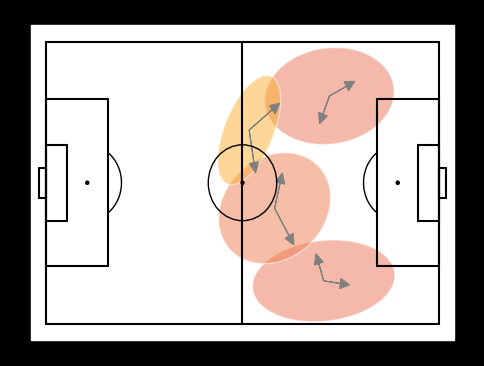

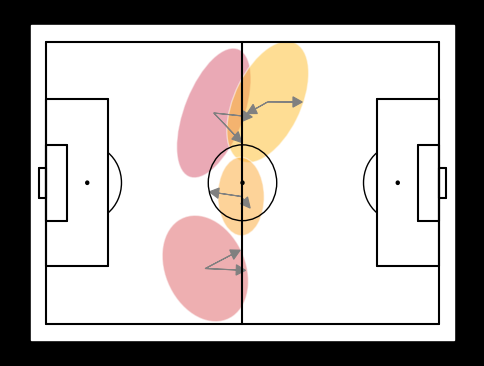

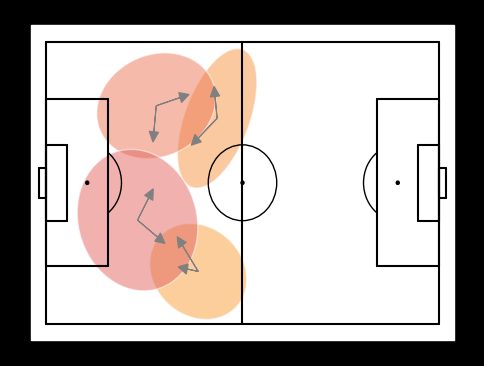

In [19]:
action_name = "pass"
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for state in range(n_state):
        model.emission.action_mom_[state][action_name].plot()

Model with 3 states:


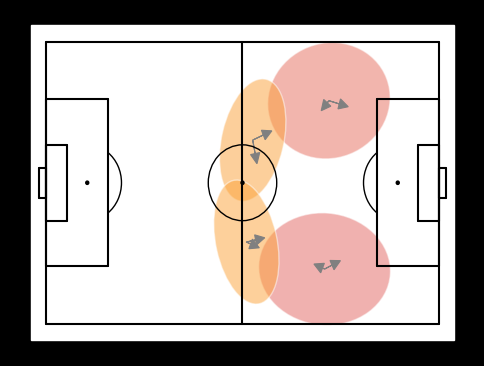

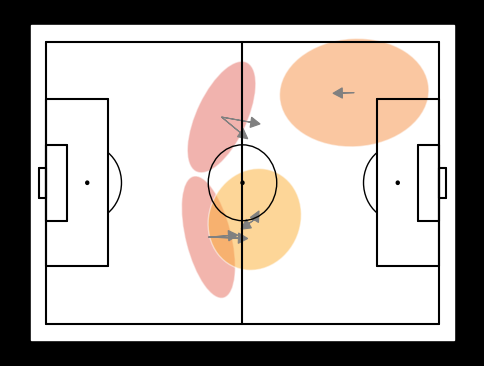

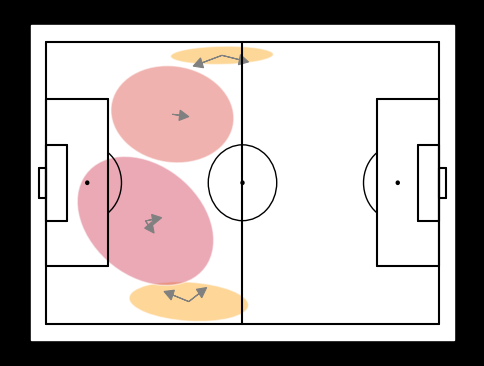

In [20]:
action_name = "dribble"
for n_state, model in models.items():
    print(f"Model with {n_state} states:")
    for state in range(n_state):
        model.emission.action_mom_[state][action_name].plot()

Action: starting
Model with 3 states:


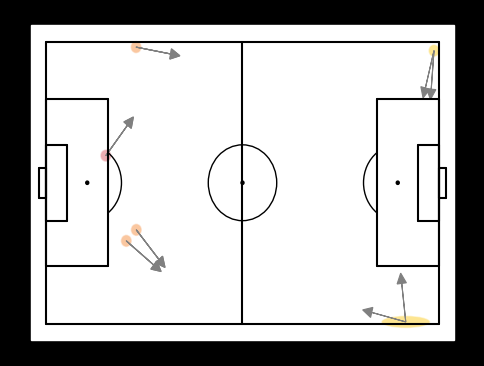

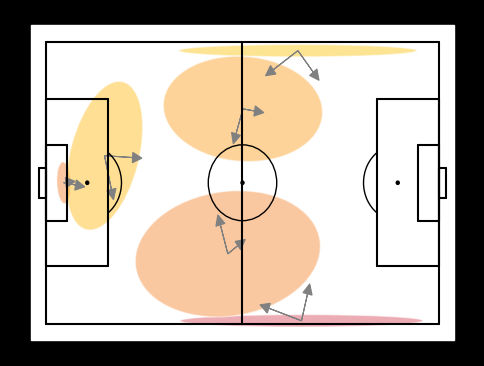

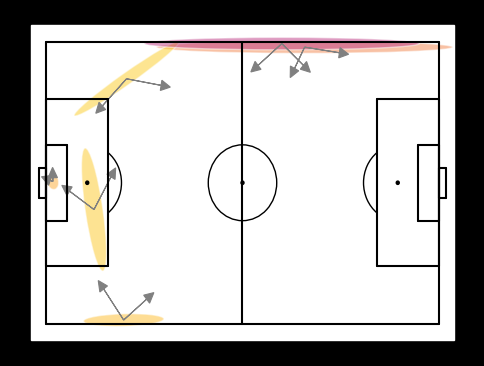

Action: pass
Model with 3 states:


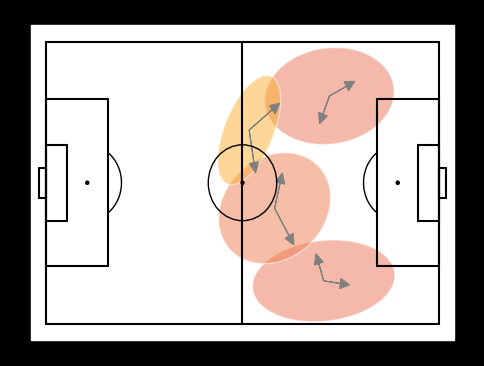

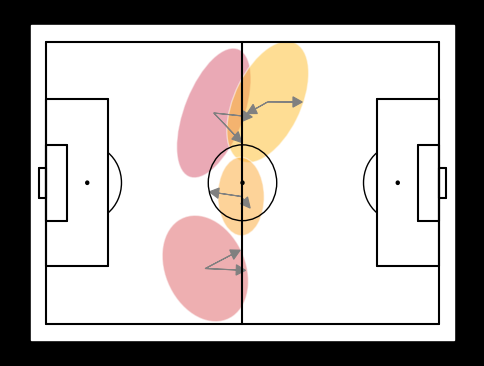

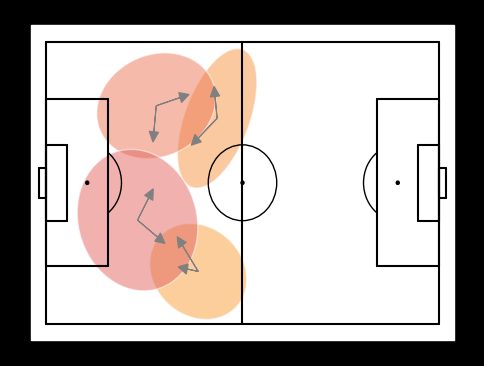

Action: dribble
Model with 3 states:


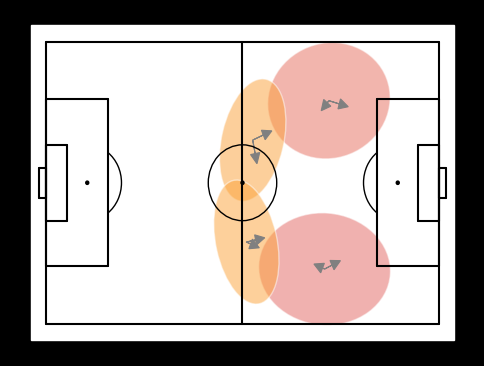

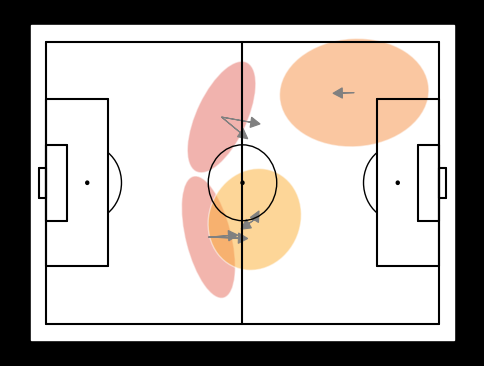

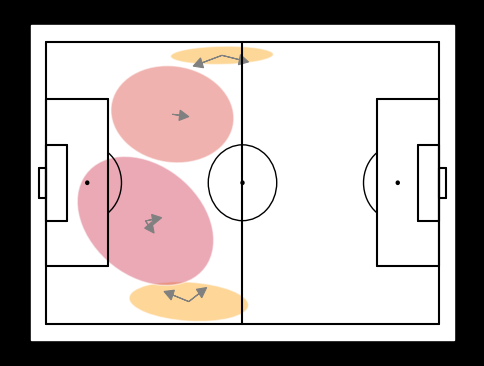

Action: shot
Model with 3 states:


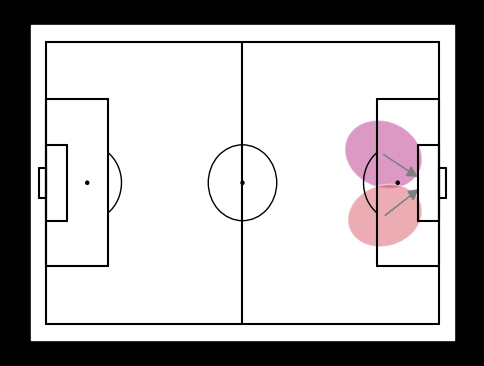

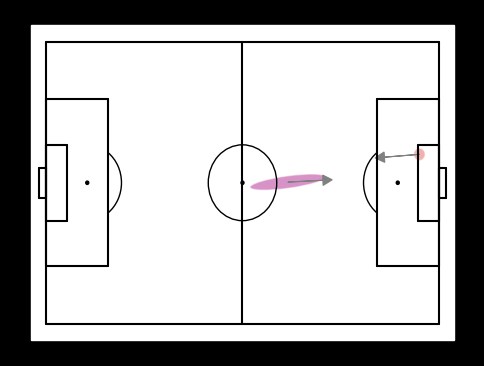

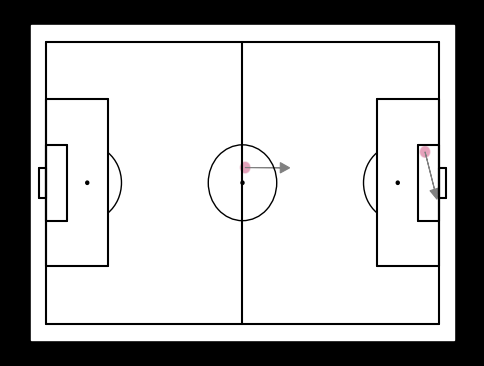

In [21]:
for action in emission_hyperparams.keys():
    print(f"Action: {action}")
    for n_state, model in models.items():
        print(f"Model with {n_state} states:")
        for state in range(n_state):
            model.emission.action_mom_[state][action].plot()